/tmp/ipykernel_10167/2171385185.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Importance', y='Feature', ax=ax[0], palette='magma')


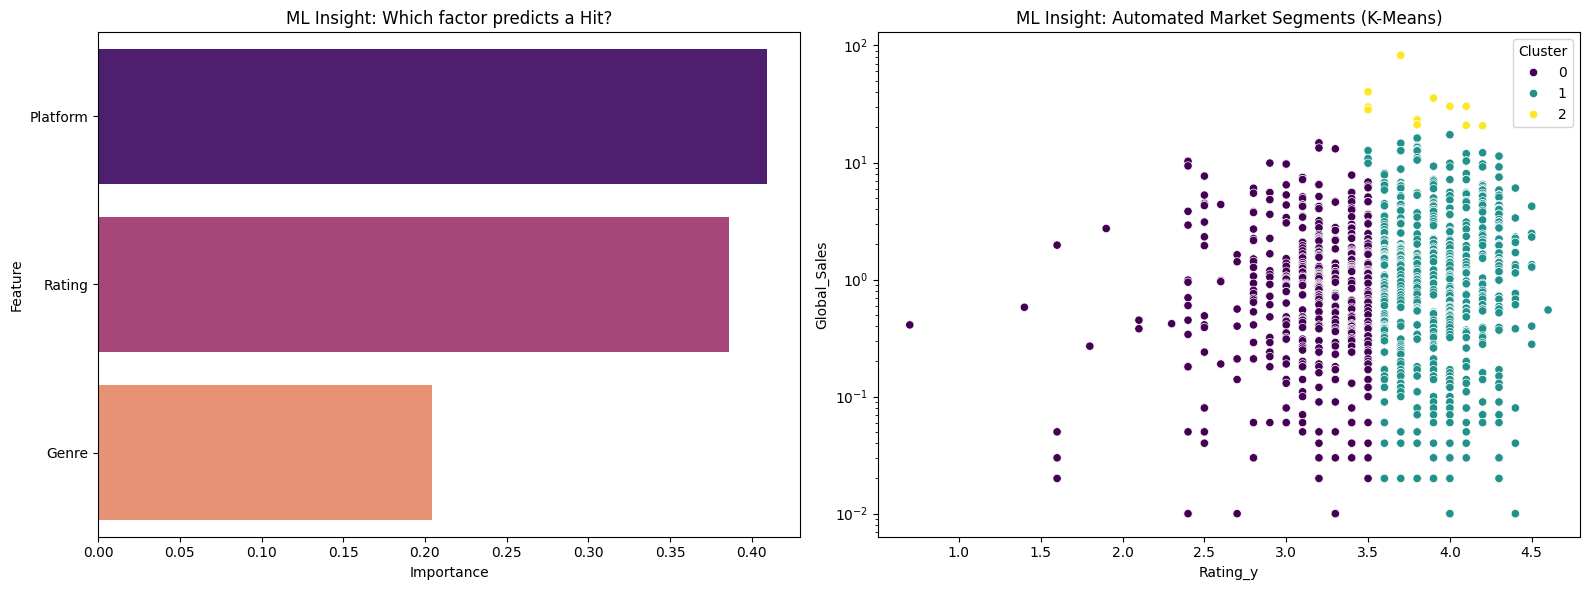


--- ML Performance Report ---
              precision    recall  f1-score   support

           0       0.76      0.77      0.76       139
           1       0.77      0.76      0.77       143

    accuracy                           0.77       282
   macro avg       0.77      0.77      0.77       282
weighted avg       0.77      0.77      0.77       282



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report


df_sales = pd.read_csv('vgsales.csv.zip')
df_popular = pd.read_csv('games.csv.zip')

df_sales['Name_Clean'] = df_sales['Name'].astype(str).str.lower().str.strip()
df_popular['Title_Clean'] = df_popular['Title'].astype(str).str.lower().str.strip()
df_merged = pd.merge(df_sales, df_popular, left_on='Name_Clean', right_on='Title_Clean', how='inner')


target_col = next((c for c in ['Rating', 'Rating_y', 'Rating_x'] if c in df_merged.columns), None)

if target_col:
    df_merged[target_col] = pd.to_numeric(df_merged[target_col], errors='coerce')
    df_merged['Global_Sales'] = pd.to_numeric(df_merged['Global_Sales'], errors='coerce')
    df_merged = df_merged.dropna(subset=['Global_Sales', target_col, 'Genre', 'Platform'])
    sales_median = df_merged['Global_Sales'].median()
    df_merged['Is_Hit'] = (df_merged['Global_Sales'] > sales_median).astype(int)
    le_genre = LabelEncoder()
    le_plat = LabelEncoder()
    df_merged['Genre_Enc'] = le_genre.fit_transform(df_merged['Genre'])
    df_merged['Platform_Enc'] = le_plat.fit_transform(df_merged['Platform'])
    X = df_merged[[target_col, 'Genre_Enc', 'Platform_Enc']]
    y = df_merged['Is_Hit']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    scaler = StandardScaler()
    cluster_scaled = scaler.fit_transform(df_merged[[target_col, 'Global_Sales']])
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_merged['Cluster'] = kmeans.fit_predict(cluster_scaled)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    importances = pd.DataFrame({'Feature': ['Rating', 'Genre', 'Platform'],
                                'Importance': rf.feature_importances_})
    importances = importances.sort_values(by='Importance', ascending=False)
    sns.barplot(data=importances, x='Importance', y='Feature', ax=ax[0], palette='magma')
    ax[0].set_title('ML Insight: Which factor predicts a Hit?')

    sns.scatterplot(data=df_merged, x=target_col, y='Global_Sales', hue='Cluster', palette='viridis', ax=ax[1])
    ax[1].set_yscale('log')
    ax[1].set_title('ML Insight: Automated Market Segments (K-Means)')

    plt.tight_layout()
    plt.show()

    print("\n--- ML Performance Report ---")
    print(classification_report(y_test, rf.predict(X_test)))
else:
    print("Could not find rating column. Check your dataset headers!")